In [1]:
# 📚 Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# 📁 Load Dataset
data = pd.read_csv("data/WineQT.csv")  # Save your given data as wine_quality.csv

# 🎯 Target column: quality
# Convert quality into binary (1 = good, 0 = bad)
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 6 else 0)

# 🧩 Split features and target
X = data.drop(['quality', 'Id'], axis=1)
y = data['quality']

# 🔀 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ⚖️ Feature Scaling (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🌲 1️⃣ Random Forest Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# ⚙️ 2️⃣ Support Vector Machine (SVM)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

# 📊 Model Evaluation Function
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n📘 {model_name} Evaluation:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

# 🧾 Evaluate Both Models
evaluate_model(y_test, rf_pred, "Random Forest")
evaluate_model(y_test, svm_pred, "SVM")

# 🩵 ROC-AUC Scores
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
svm_auc = roc_auc_score(y_test, svm_model.predict_proba(X_test_scaled)[:,1])
print("\nROC-AUC (Random Forest):", rf_auc)
print("ROC-AUC (SVM):", svm_auc)



📘 Random Forest Evaluation:
Accuracy: 0.7725947521865889
Precision: 0.8228571428571428
Recall: 0.7539267015706806
F1-score: 0.7868852459016393
Confusion Matrix:
 [[121  31]
 [ 47 144]]

📘 SVM Evaluation:
Accuracy: 0.7638483965014577
Precision: 0.7989130434782609
Recall: 0.7696335078534031
F1-score: 0.784
Confusion Matrix:
 [[115  37]
 [ 44 147]]

ROC-AUC (Random Forest): 0.8454464039680352
ROC-AUC (SVM): 0.8492008817856158


Dataset shape: (1143, 13)

First few rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4       

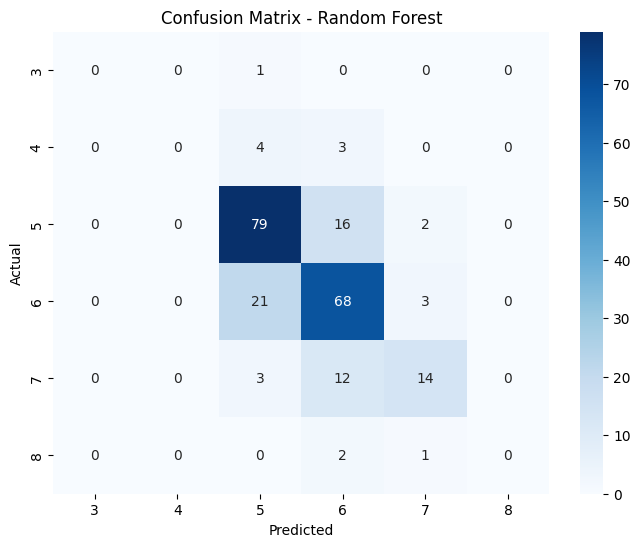


Classification Report for Random Forest:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.73      0.81      0.77        97
           6       0.67      0.74      0.70        92
           7       0.70      0.48      0.57        29
           8       0.00      0.00      0.00         3

    accuracy                           0.70       229
   macro avg       0.35      0.34      0.34       229
weighted avg       0.67      0.70      0.68       229


SVM Performance:
Accuracy: 0.6725
Precision: 0.6475
Recall: 0.6725
F1-Score: 0.6456
ROC-AUC: 0.8170


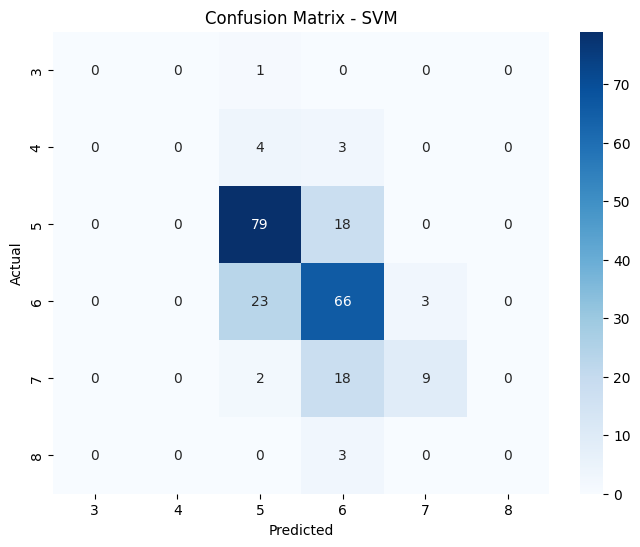


Classification Report for SVM:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.72      0.81      0.77        97
           6       0.61      0.72      0.66        92
           7       0.75      0.31      0.44        29
           8       0.00      0.00      0.00         3

    accuracy                           0.67       229
   macro avg       0.35      0.31      0.31       229
weighted avg       0.65      0.67      0.65       229



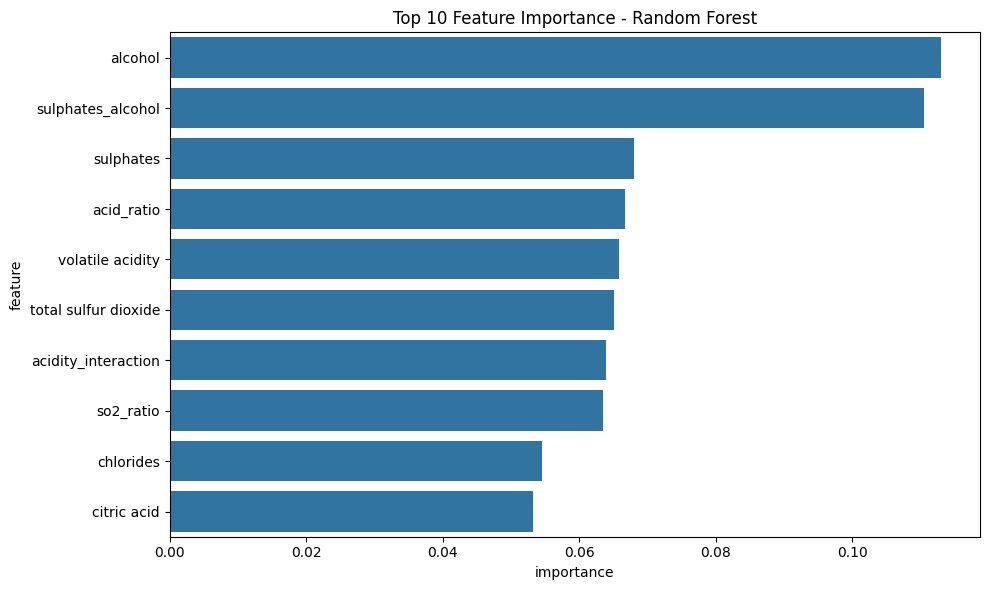


Model Comparison:
      Metric  Random Forest       SVM
0   Accuracy       0.703057  0.672489
1  Precision       0.668971  0.647489
2     Recall       0.703057  0.672489
3   F1-Score       0.681928  0.645632
4    ROC-AUC       0.837326  0.816956


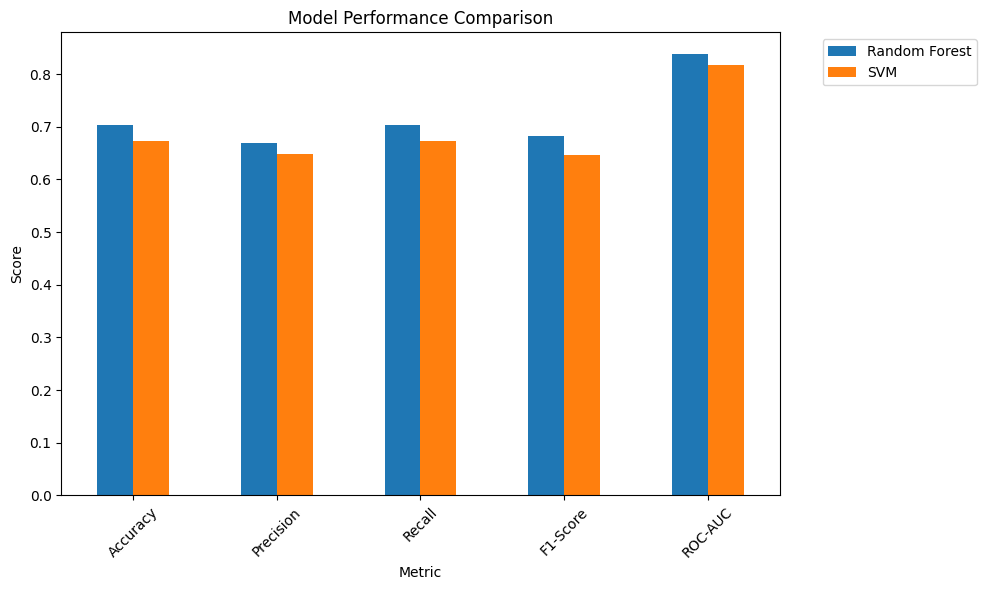


Cross-Validation Scores:
Random Forest CV: 0.6510 (+/- 0.0393)
SVM CV: 0.6149 (+/- 0.0383)

Example prediction on test sample:
Actual quality: 6
Random Forest prediction: 6
SVM prediction: 7


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# Load the dataset from CSV file
def load_data(file_path):
    """Load wine quality dataset from CSV file"""
    df = pd.read_csv(file_path)
    print("Dataset shape:", df.shape)
    print("\nFirst few rows:")
    print(df.head())
    print("\nDataset info:")
    print(df.info())
    return df

# Data preprocessing
def preprocess_data(df):
    """Preprocess the wine quality data"""
    # Check for missing values
    print("\nMissing values:")
    print(df.isnull().sum())
    
    # Remove ID column as it's not a feature
    if 'Id' in df.columns:
        df = df.drop('Id', axis=1)
    
    # Explore the target variable
    print("\nQuality distribution:")
    print(df['quality'].value_counts().sort_index())
    
    # Handle quality as multiclass (3-9) or create binary classification
    # For this example, we'll use multiclass
    X = df.drop('quality', axis=1)
    y = df['quality']
    
    return X, y

# Feature engineering
def engineer_features(X, y):
    """Create additional features and handle class imbalance"""
    # Create some additional features that might be relevant for wine quality
    X_fe = X.copy()
    
    # Ratio features
    X_fe['acid_ratio'] = X_fe['fixed acidity'] / (X_fe['volatile acidity'] + 1e-8)
    X_fe['so2_ratio'] = X_fe['free sulfur dioxide'] / (X_fe['total sulfur dioxide'] + 1e-8)
    X_fe['sugar_alcohol_ratio'] = X_fe['residual sugar'] / (X_fe['alcohol'] + 1e-8)
    
    # Interaction terms
    X_fe['acidity_interaction'] = X_fe['fixed acidity'] * X_fe['volatile acidity']
    X_fe['sulphates_alcohol'] = X_fe['sulphates'] * X_fe['alcohol']
    
    return X_fe

# Model training and evaluation
class WineQualityPredictor:
    def __init__(self):
        self.rf_model = RandomForestClassifier(random_state=42)
        self.svm_model = SVC(random_state=42, probability=True)
        self.scaler = StandardScaler()
        self.is_fitted = False
        
    def prepare_data(self, X, y, test_size=0.2):
        """Prepare train-test split and scale features"""
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )
        
        # Scale features for SVM
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test
    
    def train_random_forest(self, X_train, y_train):
        """Train Random Forest with hyperparameter tuning"""
        print("Training Random Forest...")
        
        param_grid = {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
        
        grid_search = GridSearchCV(
            self.rf_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1
        )
        grid_search.fit(X_train, y_train)
        
        self.rf_model = grid_search.best_estimator_
        print(f"Best RF parameters: {grid_search.best_params_}")
        return grid_search.best_score_
    
    def train_svm(self, X_train_scaled, y_train):
        """Train SVM with hyperparameter tuning"""
        print("Training SVM...")
        
        param_grid = {
            'C': [0.1, 1, 10],
            'gamma': ['scale', 'auto'],
            'kernel': ['rbf', 'linear']
        }
        
        grid_search = GridSearchCV(
            self.svm_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1
        )
        grid_search.fit(X_train_scaled, y_train)
        
        self.svm_model = grid_search.best_estimator_
        print(f"Best SVM parameters: {grid_search.best_params_}")
        return grid_search.best_score_
    
    def evaluate_model(self, model, X_test, X_test_scaled, y_test, model_name):
        """Comprehensive model evaluation"""
        if model_name == 'Random Forest':
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)
        else:  # SVM
            y_pred = model.predict(X_test_scaled)
            y_pred_proba = model.predict_proba(X_test_scaled)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # For multiclass ROC-AUC (One-vs-Rest)
        try:
            roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
        except:
            roc_auc = 0.5  # Default if calculation fails
        
        print(f"\n{model_name} Performance:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(f"ROC-AUC: {roc_auc:.4f}")
        
        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        self.plot_confusion_matrix(cm, model_name)
        
        # Classification Report
        print(f"\nClassification Report for {model_name}:")
        print(classification_report(y_test, y_pred, zero_division=0))
        
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
    
    def plot_confusion_matrix(self, cm, model_name):
        """Plot confusion matrix"""
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=sorted(set(y_test)), 
                   yticklabels=sorted(set(y_test)))
        plt.title(f'Confusion Matrix - {model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()
    
    def plot_feature_importance(self, X):
        """Plot feature importance for Random Forest"""
        if hasattr(self.rf_model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'feature': X.columns,
                'importance': self.rf_model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            plt.figure(figsize=(10, 6))
            sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
            plt.title('Top 10 Feature Importance - Random Forest')
            plt.tight_layout()
            plt.show()
    
    def compare_models(self, rf_results, svm_results):
        """Compare model performances"""
        comparison_df = pd.DataFrame({
            'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
            'Random Forest': [
                rf_results['accuracy'],
                rf_results['precision'],
                rf_results['recall'],
                rf_results['f1'],
                rf_results['roc_auc']
            ],
            'SVM': [
                svm_results['accuracy'],
                svm_results['precision'],
                svm_results['recall'],
                svm_results['f1'],
                svm_results['roc_auc']
            ]
        })
        
        print("\nModel Comparison:")
        print(comparison_df)
        
        # Plot comparison
        comparison_df.set_index('Metric').plot(kind='bar', figsize=(10, 6))
        plt.title('Model Performance Comparison')
        plt.ylabel('Score')
        plt.xticks(rotation=45)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# Main execution
if __name__ == "__main__":
    # Load your data (replace with your actual file path)
    file_path = "data/WineQT.csv"  # Update this path
    df = load_data(file_path)
    
    # Preprocess data
    X, y = preprocess_data(df)
    
    # Feature engineering
    X_fe = engineer_features(X, y)
    
    # Initialize predictor
    predictor = WineQualityPredictor()
    
    # Prepare data
    X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test = predictor.prepare_data(X_fe, y)
    
    print(f"Training set size: {X_train.shape}")
    print(f"Test set size: {X_test.shape}")
    print(f"Unique classes in target: {sorted(y.unique())}")
    
    # Train models
    rf_cv_score = predictor.train_random_forest(X_train, y_train)
    svm_cv_score = predictor.train_svm(X_train_scaled, y_train)
    
    print(f"\nRandom Forest CV Score: {rf_cv_score:.4f}")
    print(f"SVM CV Score: {svm_cv_score:.4f}")
    
    # Evaluate models
    rf_results = predictor.evaluate_model(
        predictor.rf_model, X_test, X_test_scaled, y_test, 'Random Forest'
    )
    
    svm_results = predictor.evaluate_model(
        predictor.svm_model, X_test, X_test_scaled, y_test, 'SVM'
    )
    
    # Feature importance
    predictor.plot_feature_importance(X_fe)
    
    # Model comparison
    predictor.compare_models(rf_results, svm_results)
    
    # Cross-validation scores
    print("\nCross-Validation Scores:")
    rf_cv_scores = cross_val_score(predictor.rf_model, X_train, y_train, cv=5)
    svm_cv_scores = cross_val_score(predictor.svm_model, X_train_scaled, y_train, cv=5)
    
    print(f"Random Forest CV: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std() * 2:.4f})")
    print(f"SVM CV: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std() * 2:.4f})")

    # Predict on new data example
    print("\nExample prediction on test sample:")
    sample_idx = 0
    sample = X_test.iloc[sample_idx:sample_idx+1]
    sample_scaled = predictor.scaler.transform(sample)
    
    rf_pred = predictor.rf_model.predict(sample)[0]
    svm_pred = predictor.svm_model.predict(sample_scaled)[0]
    actual = y_test.iloc[sample_idx]
    
    print(f"Actual quality: {actual}")
    print(f"Random Forest prediction: {rf_pred}")
    print(f"SVM prediction: {svm_pred}")

In [ ]:
# Add this function for binary classification
def create_binary_target(y, threshold=6):
    """Convert quality to binary: 0 (bad) if <= threshold, 1 (good) if > threshold"""
    return (y > threshold).astype(int)

# In the main execution, replace:
# X, y = preprocess_data(df)
# with:
X, y_original = preprocess_data(df)
y = create_binary_target(y_original, threshold=6)
print("\nBinary target distribution:")
print(y.value_counts())